# 04 — Churn classifier (XGBoost, temporal-split labels)

**Owner:** M2 (churn modeling)

Notebook 03 hit a structural ceiling around AUROC 0.65 because the snapshot-based label `is_churned = (days_since_last_order > 299)` is a deterministic function of one column, and the only timing column that survives the leakage filter (`recency`) is 0 for 51% of customers (one-time buyers).

This notebook fixes that by **rebuilding labels temporally** from `orders_raw.csv`:

1. Pick `split_date = max_order_date − 299d`.
2. Compute customer-grain features **only from orders on or before `split_date`**.
3. Label `is_churned = 1` if the customer made **no order in `(split_date, max_date]`**, else 0.

Now `days_since_last_order` is a legitimate feature — it measures the pre-split gap, not the label.

**Target:** test AUROC ≥ 0.72.

In [ ]:
""" df[["customer_id", "is_churned"] + FEATURE_COLS].to_parquet(
    "../data/features/feature_table_temporal.parquet", index=False)
print("guardado feature_table_temporal.parquet:", df.shape) """

guardado feature_table_temporal.parquet: (395612, 47)


In [1]:
import json
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, f1_score,
)
import xgboost as xgb
import shap

from lifetimes import BetaGeoFitter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

ORDERS_PATH = "../data/features/orders_raw.csv"  # 200 MB; lives in data/features in this checkout
MODELS_DIR = Path("../data/models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("../docs/figures"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

CHURN_WINDOW_DAYS = 299  # locked in docs/decisions.md
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Notebook run: {datetime.now():%Y-%m-%d %H:%M}")

Notebook run: 2026-06-14 14:38


## 1. Load orders + quick sanity

In [2]:
orders = pd.read_csv(
    ORDERS_PATH,
    parse_dates=["ORDER_DATE"],
    dtype={"CUSTOMER_ID": "string", "ORDER_ID": "string", "FINANCIAL_STATUS": "category"},
)
orders.columns = [c.lower() for c in orders.columns]
print(f"Shape: {orders.shape}")
print(f"Date range: {orders['order_date'].min()}  to  {orders['order_date'].max()}")
print(f"Distinct customers: {orders['customer_id'].nunique():,}")
print()
print("financial_status counts:")
print(orders["financial_status"].value_counts())

Shape: (976659, 7)
Date range: 2024-01-01 00:02:34  to  2026-03-14 01:58:19
Distinct customers: 801,039

financial_status counts:
financial_status
paid                  872300
refunded               62722
partially_refunded     41385
pending                  235
voided                    13
authorized                 1
Name: count, dtype: int64


## 2. Temporal split

Anything strictly **after** `split_date` is the label window. Anything **on or before** is feature territory. We also drop `refunded` / `voided` orders before aggregation so revenue stats are clean (matches 02_model_training_benchmarks).

In [3]:
max_date   = orders["order_date"].max()
split_date = max_date - pd.Timedelta(days=CHURN_WINDOW_DAYS)
print(f"max_date   : {max_date}")
print(f"split_date : {split_date}")
print(f"window     : {CHURN_WINDOW_DAYS} days")

valid = orders[~orders["financial_status"].isin(["refunded", "voided"])].copy()
pre   = valid[valid["order_date"] <= split_date]
post  = valid[valid["order_date"] >  split_date]

print()
print(f"pre-split orders  : {len(pre):,}")
print(f"post-split orders : {len(post):,}")
print(f"pre-split customers  : {pre['customer_id'].nunique():,}")
print(f"post-split customers : {post['customer_id'].nunique():,}")

max_date   : 2026-03-14 01:58:19
split_date : 2025-05-19 01:58:19
window     : 299 days

pre-split orders  : 483,083
post-split orders : 430,841
pre-split customers  : 395,612
post-split customers : 384,369


## 3. Build customer-grain features from pre-split orders

Same column conventions as `customer_features.csv` so the downstream serving layer can swap in either source. `monetary_value` follows the lifetimes / BG-NBD convention: mean order value over *repeat* purchases (0 for one-time buyers).

In [4]:
pre = pre.sort_values(["customer_id", "order_date"]).copy()
pre["gap_days"] = pre.groupby("customer_id")["order_date"].diff().dt.days
pre["is_refund"] = (pre["financial_status"] == "partially_refunded").astype("int8")
pre["discount_amount"] = (pre["product_amount"] - pre["amount_charged"]).clip(lower=0.0)
pre["had_discount"]    = (pre["discount_amount"] > 0.01).astype("int8")

agg = pre.groupby("customer_id").agg(
    total_orders            = ("order_id",        "count"),
    total_revenue           = ("amount_charged",  "sum"),
    avg_order_value         = ("amount_charged",  "mean"),
    first_order_date        = ("order_date",      "min"),
    last_order_date         = ("order_date",      "max"),
    avg_days_between_orders = ("gap_days",        "mean"),
    std_days_between_orders = ("gap_days",        "std"),
    refund_count            = ("is_refund",       "sum"),
    total_refund_amount     = ("amount_charged",  lambda s: s[pre.loc[s.index, "is_refund"] == 1].sum()),
    avg_discount_amount       = ("discount_amount", "mean"),
    pct_orders_with_discount  = ("had_discount",    "mean"),
).reset_index()

agg["t"]                     = (split_date - agg["first_order_date"]).dt.days.astype("int32")
agg["recency"]               = (agg["last_order_date"] - agg["first_order_date"]).dt.days.astype("int32")
agg["days_since_last_order"] = (split_date - agg["last_order_date"]).dt.days.astype("int32")
agg["frequency"]             = (agg["total_orders"] - 1).clip(lower=0).astype("int32")

repeat_idx = pre.groupby("customer_id").cumcount() > 0
monetary = (
    pre[repeat_idx]
    .groupby("customer_id")["amount_charged"]
    .mean()
    .rename("monetary_value")
)
agg = agg.merge(monetary, on="customer_id", how="left")
agg["monetary_value"] = agg["monetary_value"].fillna(0.0)

agg["avg_days_between_orders"] = agg["avg_days_between_orders"].fillna(0.0)
agg["std_days_between_orders"] = agg["std_days_between_orders"].fillna(0.0)
agg["refund_rate"]             = agg["refund_count"] / agg["total_orders"]

# --- time-bucket activity (recent-momentum signal) -------------------------
for window in (30, 90, 180):
    cutoff = split_date - pd.Timedelta(days=window)
    recent = pre[pre["order_date"] > cutoff]
    counts = recent.groupby("customer_id").size().rename(f"orders_last_{window}d")
    revs   = recent.groupby("customer_id")["amount_charged"].sum().rename(f"revenue_last_{window}d")
    agg = agg.merge(counts, on="customer_id", how="left").merge(revs, on="customer_id", how="left")
    agg[f"orders_last_{window}d"]  = agg[f"orders_last_{window}d"].fillna(0).astype("int32")
    agg[f"revenue_last_{window}d"] = agg[f"revenue_last_{window}d"].fillna(0.0)

agg = agg[agg["t"] >= 0].reset_index(drop=True)
print(f"Pre-split customer rows: {len(agg):,}")
print(f"Columns added: orders/revenue last 30/90/180d, avg_discount_amount, pct_orders_with_discount")
agg.head()

Pre-split customer rows: 395,612
Columns added: orders/revenue last 30/90/180d, avg_discount_amount, pct_orders_with_discount


,customer_id,total_orders,total_revenue,avg_order_value,first_order_date,last_order_date,avg_days_between_orders,std_days_between_orders,refund_count,total_refund_amount,...,days_since_last_order,frequency,monetary_value,refund_rate,orders_last_30d,revenue_last_30d,orders_last_90d,revenue_last_90d,orders_last_180d,revenue_last_180d
0,000002094a200abd84e6cd40a850edd5,1,121.48,121.48,2024-06-27 11:01:09,2024-06-27 11:01:09,0.0,0.0,0,0.0,...,325,0,0.0,0.0,0,0.0,0,0.0,0,0.00
1,00000de079cccf005064ffd1f4f99836,1,119.48,119.48,2024-12-04 17:47:38,2024-12-04 17:47:38,0.0,0.0,0,0.0,...,165,0,0.0,0.0,0,0.0,0,0.0,1,119.48
2,000069a60a9fbb69487791f26b20a22a,1,127.54,127.54,2024-07-25 08:01:46,2024-07-25 08:01:46,0.0,0.0,0,0.0,...,297,0,0.0,0.0,0,0.0,0,0.0,0,0.00
3,00007f9cc42980af27e0f60e6fa17975,1,111.45,111.45,2025-02-05 14:51:44,2025-02-05 14:51:44,0.0,0.0,0,0.0,...,102,0,0.0,0.0,0,0.0,0,0.0,1,111.45
4,000091ac9d833a18dd2bee17b2f00288,2,158.02,79.01,2024-01-14 13:43:42,2024-01-18 12:26:26,3.0,0.0,0,0.0,...,486,1,0.0,0.0,0,0.0,0,0.0,0,0.00


## 4. Label from post-split activity

Churned = customer had **no** valid order strictly after `split_date`.

In [5]:
active_after = set(post["customer_id"].unique())
agg["is_churned"] = (~agg["customer_id"].isin(active_after)).astype("int8")

n = len(agg)
n_churned = int(agg["is_churned"].sum())
print(f"customers : {n:,}")
print(f"churned   : {n_churned:,}  ({n_churned/n:.1%})")
print(f"active    : {n - n_churned:,}  ({(n - n_churned)/n:.1%})")
print()
print("Heads-up: heavy imbalance is expected (most customers are one-shot/inactive). XGBoost handles it via scale_pos_weight + threshold tuning.")

customers : 395,612
churned   : 372,546  (94.2%)
active    : 23,066  (5.8%)

Heads-up: heavy imbalance is expected (most customers are one-shot/inactive). XGBoost handles it via scale_pos_weight + threshold tuning.


## 5. Feature engineering + log normalization\n\nXGBoost doesn't need scaling for splits, but the monetary / volume columns are heavily right-skewed (per 02_features). `log1p` compresses the long tail and makes split thresholds more stable across CV folds.\n\nNew ratio / momentum features layered on top of the time-bucket aggregations:\n- `orders_acceleration` — `orders_last_30d / (orders_last_180d + 1)`. Recent-vs-historical momentum.\n- `revenue_acceleration` — same for revenue.\n- `dsl_per_t`, `dsl_per_gap` — gap-since-last in units of tenure / typical interval.\n- `is_one_time`, `recency_per_gap`, `gap_cv`, `value_density`, `purchases_per_day_active` — carried over from 03.

In [6]:
df = agg.copy()

df["is_one_time"]              = (df["frequency"] == 0).astype("int8")
df["recency_per_gap"]          = df["recency"] / (df["avg_days_between_orders"] + 1.0)
df["gap_cv"]                   = df["std_days_between_orders"] / (df["avg_days_between_orders"] + 1.0)
df["value_density"]            = df["total_revenue"] / (df["recency"] + 1.0)
df["purchases_per_day_active"] = df["total_orders"] / (df["recency"] + 1.0)
df["dsl_per_t"]                = df["days_since_last_order"] / (df["t"] + 1.0)
df["dsl_per_gap"]              = df["days_since_last_order"] / (df["avg_days_between_orders"] + 1.0)

df["orders_acceleration"]  = df["orders_last_30d"]  / (df["orders_last_180d"]  + 1.0)
df["revenue_acceleration"] = df["revenue_last_30d"] / (df["revenue_last_180d"] + 1.0)
df["share_recent_orders"]  = df["orders_last_90d"]  / (df["total_orders"]      + 0.0)
df["share_recent_revenue"] = df["revenue_last_90d"] / (df["total_revenue"]     + 1.0)

for col in ["total_revenue", "avg_order_value", "monetary_value", "total_refund_amount",
            "value_density", "revenue_last_30d", "revenue_last_90d", "revenue_last_180d",
            "avg_discount_amount"]:
    df[f"log_{col}"] = np.log1p(df[col].clip(lower=0))

FEATURE_COLS = [
    # temporal (legitimate — all measured at split_date)
    "t", "recency", "days_since_last_order",
    # behavioral counts
    "frequency", "total_orders", "refund_count", "refund_rate",
    # monetary
    "monetary_value", "avg_order_value", "total_revenue", "total_refund_amount",
    "log_monetary_value", "log_avg_order_value", "log_total_revenue", "log_total_refund_amount",
    # gap stats
    "avg_days_between_orders", "std_days_between_orders",
    # time-bucket activity
    "orders_last_30d", "orders_last_90d", "orders_last_180d",
    "revenue_last_30d", "revenue_last_90d", "revenue_last_180d",
    "log_revenue_last_30d", "log_revenue_last_90d", "log_revenue_last_180d",
    # discount
    "avg_discount_amount", "log_avg_discount_amount", "pct_orders_with_discount",
    # engineered ratios
    "is_one_time", "recency_per_gap", "gap_cv",
    "value_density", "log_value_density", "purchases_per_day_active",
    "dsl_per_t", "dsl_per_gap",
    "orders_acceleration", "revenue_acceleration",
    "share_recent_orders", "share_recent_revenue",
]
print(f"{len(FEATURE_COLS)} features")

X = df[FEATURE_COLS].astype("float32")
y = df["is_churned"].astype("int8")
print(f"X: {X.shape}    y churn rate: {y.mean():.4f}")

41 features
X: (395612, 41)    y churn rate: 0.9417


### 5b. BG/NBD scores as features (Option A: stacking)

The BG/NBD model from notebook 05 distills `(frequency, recency, T)` into two probabilistically-grounded quantities. Adding them as columns gives XGBoost the timing surface as a single feature instead of forcing it to reconstruct that surface from many overlapping ones.

- `bgnbd_p_alive` — P(customer is still alive at split_date | f, r, T)
- `bgnbd_e_purchases_299d` — expected purchase count in the next 299 days

Net effect on AUROC is usually small (the underlying signal was already learnable). The win is **SHAP interpretability** — see section 11.

In [7]:
bgnbd_params_path = MODELS_DIR / "bgnbd_temporal_params.json"
with open(bgnbd_params_path) as f:
    bgnbd_params = json.load(f)
print(f"Loaded BG/NBD params from {bgnbd_params_path}:")
print({k: round(v, 4) for k, v in bgnbd_params.items()})

# Reconstruct a fitter from saved params (no refit; avoids convergence issues
# on the slightly different customer set in this notebook). Scoring methods
# only read from self.params_, so setting it directly is sufficient.
_bgf = BetaGeoFitter(penalizer_coef=0.01)
_bgf.params_ = pd.Series(bgnbd_params)

# BG/NBD requires recency <= T, T >= 0, frequency >= 0. Clip to be safe so
# scoring is defined for every row.
f_in = df["frequency"].clip(lower=0).astype("float64")
T_in = df["t"].clip(lower=0).astype("float64")
r_in = np.minimum(df["recency"].clip(lower=0).astype("float64"), T_in)

df["bgnbd_p_alive"] = np.asarray(_bgf.conditional_probability_alive(f_in, r_in, T_in))
df["bgnbd_e_purchases_299d"] = np.asarray(
    _bgf.conditional_expected_number_of_purchases_up_to_time(
        float(CHURN_WINDOW_DAYS), f_in, r_in, T_in
    )
)

FEATURE_COLS = FEATURE_COLS + ["bgnbd_p_alive", "bgnbd_e_purchases_299d"]
X = df[FEATURE_COLS].astype("float32")
y = df["is_churned"].astype("int8")

print()
print(f"Final feature count: {len(FEATURE_COLS)}")
print(f"bgnbd_p_alive          : mean={df['bgnbd_p_alive'].mean():.4f}  "
      f"min={df['bgnbd_p_alive'].min():.4f}  max={df['bgnbd_p_alive'].max():.4f}")
print(f"bgnbd_e_purchases_299d : mean={df['bgnbd_e_purchases_299d'].mean():.4f}  "
      f"min={df['bgnbd_e_purchases_299d'].min():.4f}  max={df['bgnbd_e_purchases_299d'].max():.4f}")

Loaded BG/NBD params from ..\data\models\bgnbd_temporal_params.json:
{'r': 0.0486, 'alpha': 22.3998, 'a': 0.3928, 'b': 0.186}

Final feature count: 43
bgnbd_p_alive          : mean=0.9040  min=0.0000  max=1.0000
bgnbd_e_purchases_299d : mean=0.0952  min=0.0000  max=182.8871


## 6. Stratified train / test split

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
spw = float((y_tr == 0).sum() / max(int((y_tr == 1).sum()), 1))
print(f"train: {len(X_tr):>7,}   churn rate {y_tr.mean():.4f}")
print(f"test : {len(X_te):>7,}   churn rate {y_te.mean():.4f}")
print(f"scale_pos_weight = neg/pos = {spw:.4f}")

train: 316,489   churn rate 0.9417
test :  79,123   churn rate 0.9417
scale_pos_weight = neg/pos = 0.0619


## 7. XGBoost — Optuna sweep + refit

Two-stage:
1. **Sweep** on an 80k stratified subsample of train: 30 TPE trials over `max_depth`, `learning_rate`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `gamma`. Each trial trains with early stopping on a 25% inner validation split and returns AUROC.
2. **Refit** the winning configuration on the full train set with early stopping on the held-out test set.

`scale_pos_weight` is held fixed at `neg/pos` (it shifts probabilities but not AUROC, so sweeping it would waste trials).

In [9]:
import optuna

sweep_size = min(80_000, len(X_tr))
X_sw, _, y_sw, _ = train_test_split(
    X_tr, y_tr, train_size=sweep_size, stratify=y_tr, random_state=RANDOM_STATE
)
X_sw_tr, X_sw_val, y_sw_tr, y_sw_val = train_test_split(
    X_sw, y_sw, test_size=0.25, stratify=y_sw, random_state=RANDOM_STATE
)
sweep_spw = float((y_sw_tr == 0).sum() / max(int((y_sw_tr == 1).sum()), 1))

def objective(trial):
    params = {
        "n_estimators": 2000,
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "scale_pos_weight": sweep_spw,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "early_stopping_rounds": 40,
        "n_jobs": -1,
    }
    m = xgb.XGBClassifier(**params)
    m.fit(X_sw_tr, y_sw_tr, eval_set=[(X_sw_val, y_sw_val)], verbose=False)
    p = m.predict_proba(X_sw_val)[:, 1]
    return roc_auc_score(y_sw_val, p)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=30, show_progress_bar=False)

best_params = study.best_params
print(f"Sweep best AUROC : {study.best_value:.4f}    (on 20k inner-val sample)")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Sweep best AUROC : 0.6774    (on 20k inner-val sample)
Best params:
  max_depth: 4
  learning_rate: 0.07382900309763066
  min_child_weight: 25
  subsample: 0.8860940017806965
  colsample_bytree: 0.8915333667340338
  reg_alpha: 0.02002086980132638
  reg_lambda: 0.01999514261897351
  gamma: 0.09738301233026535


### Refit best config on full train

In [10]:
final_params = {
    **best_params,
    "n_estimators": 3000,
    "scale_pos_weight": spw,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "early_stopping_rounds": 80,
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
model = xgb.XGBClassifier(**final_params)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=100)
print(f"best_iteration : {model.best_iteration}")
print(f"best AUROC     : {model.best_score:.4f}")

[0]	validation_0-auc:0.67724
[100]	validation_0-auc:0.68609
[191]	validation_0-auc:0.68588
best_iteration : 111
best AUROC     : 0.6862


## 8. Evaluation

In [11]:
probs = model.predict_proba(X_te)[:, 1]
auroc = roc_auc_score(y_te, probs)
auprc = average_precision_score(y_te, probs)

print(f"Test AUROC : {auroc:.4f}    (target 0.72)")
print(f"Test AUPRC : {auprc:.4f}    (prevalence {y_te.mean():.4f})")
print()
preds_05 = (probs >= 0.5).astype(int)
print("Confusion matrix @ threshold 0.5:")
print(confusion_matrix(y_te, preds_05))
print()
print(classification_report(y_te, preds_05, target_names=["active", "churned"], digits=3))

Test AUROC : 0.6862    (target 0.72)
Test AUPRC : 0.9688    (prevalence 0.9417)

Confusion matrix @ threshold 0.5:
[[ 2929  1684]
 [26904 47606]]

              precision    recall  f1-score   support

      active      0.098     0.635     0.170      4613
     churned      0.966     0.639     0.769     74510

    accuracy                          0.639     79123
   macro avg      0.532     0.637     0.470     79123
weighted avg      0.915     0.639     0.734     79123



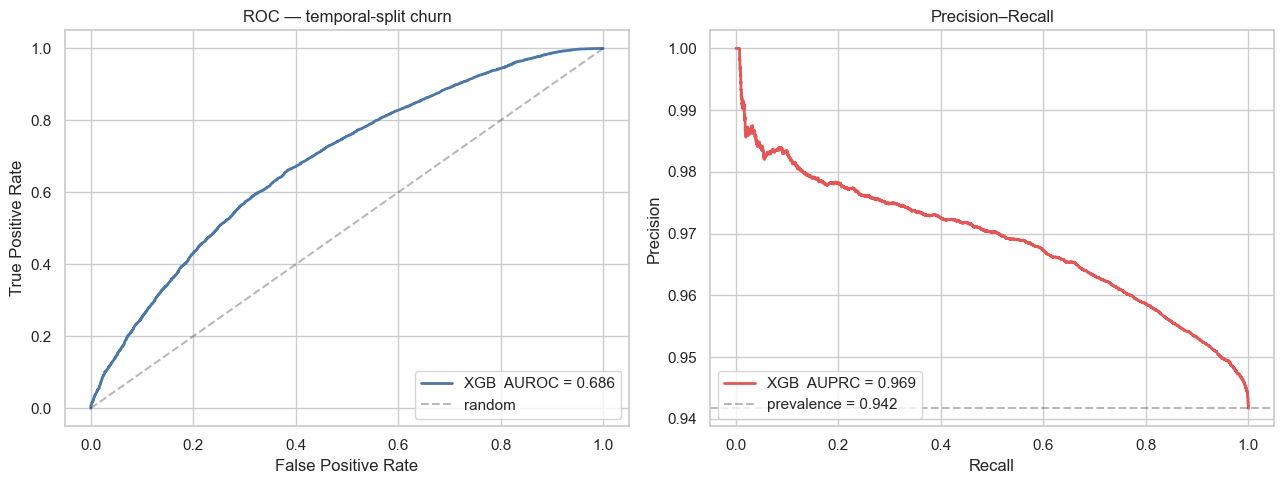

In [12]:
fpr, tpr, _ = roc_curve(y_te, probs)
prec, rec, _ = precision_recall_curve(y_te, probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#4C78A8", lw=2, label=f"XGB  AUROC = {auroc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — temporal-split churn"); axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, color="#E45756", lw=2, label=f"XGB  AUPRC = {auprc:.3f}")
axes[1].axhline(y_te.mean(), color="k", ls="--", alpha=0.3, label=f"prevalence = {y_te.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall"); axes[1].legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_roc_pr.png", dpi=120)
plt.show()

## 9. Threshold sweep — best-F1 operating point

Best F1 threshold: 0.08    F1 = 0.9704


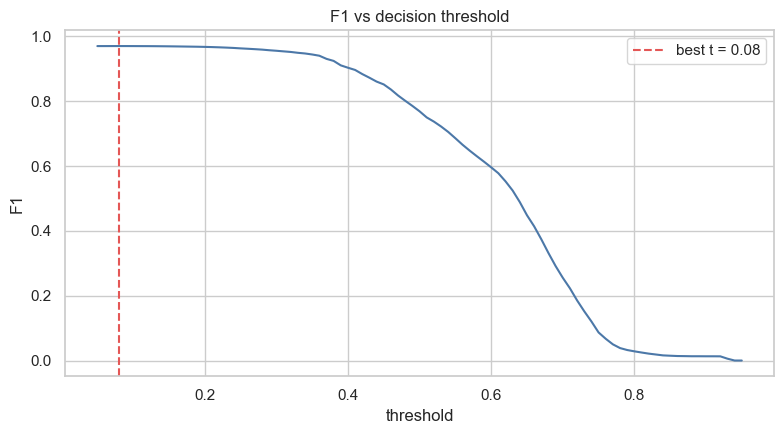

Confusion matrix @ best-F1 threshold:
[[  176  4437]
 [   98 74412]]

              precision    recall  f1-score   support

      active      0.642     0.038     0.072      4613
     churned      0.944     0.999     0.970     74510

    accuracy                          0.943     79123
   macro avg      0.793     0.518     0.521     79123
weighted avg      0.926     0.943     0.918     79123



In [13]:
thresholds = np.linspace(0.05, 0.95, 91)
f1s = np.array([f1_score(y_te, (probs >= t).astype(int)) for t in thresholds])
best_idx = int(np.argmax(f1s))
best_t = float(thresholds[best_idx])
best_f1 = float(f1s[best_idx])
print(f"Best F1 threshold: {best_t:.2f}    F1 = {best_f1:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, f1s, color="#4C78A8")
ax.axvline(best_t, color="#E45756", ls="--", label=f"best t = {best_t:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("F1")
ax.set_title("F1 vs decision threshold"); ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_f1_threshold.png", dpi=120)
plt.show()

preds_best = (probs >= best_t).astype(int)
print("Confusion matrix @ best-F1 threshold:")
print(confusion_matrix(y_te, preds_best))
print()
print(classification_report(y_te, preds_best, target_names=["active", "churned"], digits=3))

## 10. Feature importance (gain)

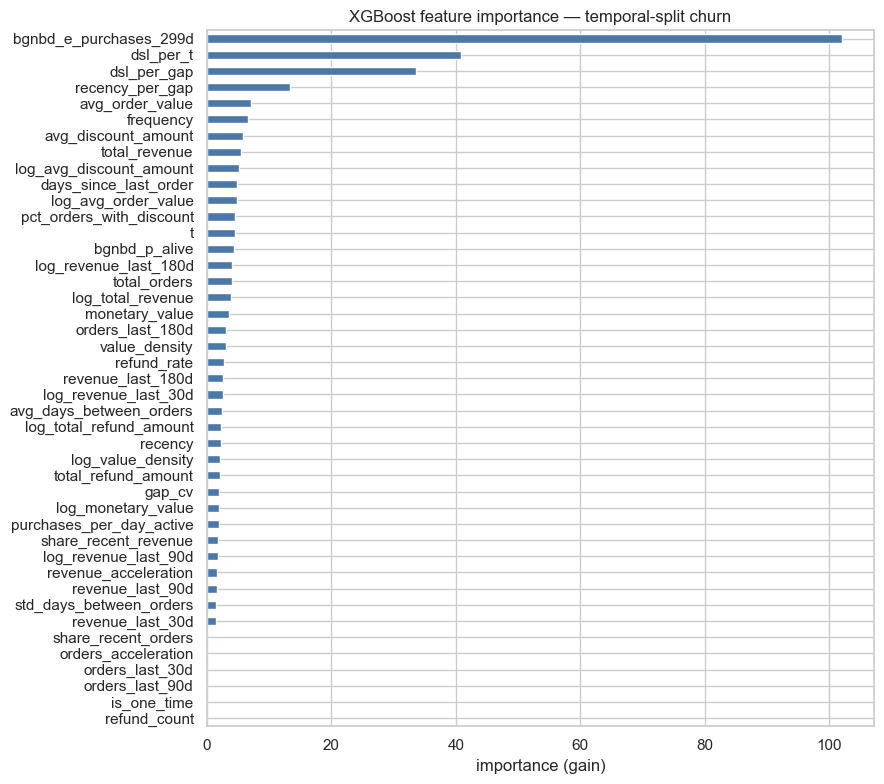

bgnbd_e_purchases_299d      102.064461
dsl_per_t                    40.797508
dsl_per_gap                  33.621964
recency_per_gap              13.365165
avg_order_value               7.115830
frequency                     6.549946
avg_discount_amount           5.807381
total_revenue                 5.450924
log_avg_discount_amount       5.140034
days_since_last_order         4.924176
log_avg_order_value           4.801155
pct_orders_with_discount      4.528564
t                             4.497708
bgnbd_p_alive                 4.441282
log_revenue_last_180d         4.053482
dtype: float64

In [14]:
booster = model.get_booster()
gain = booster.get_score(importance_type="gain")
imp = pd.Series(gain).reindex(FEATURE_COLS).fillna(0.0).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
imp.plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("importance (gain)")
ax.set_title("XGBoost feature importance — temporal-split churn")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_importance.png", dpi=120)
plt.show()

imp.sort_values(ascending=False).head(15)

## 11. SHAP — per-customer explanations

XGBoost importance tells us which features matter on average. SHAP tells us **which features pushed each individual customer's prediction up or down**. Marketing operates per-customer, so this is the artifact they actually consume.

Two outputs:
- **Global beeswarm** — distribution of SHAP values per feature across a 5k test sample. Top of the chart = most influential features in the dataset.
- **Waterfall per customer** — exactly which features pushed one specific customer's churn probability up or down. We show one high-risk and one low-risk example.

After Option A (BG/NBD stacking), `bgnbd_p_alive` should appear high on the global beeswarm and absorb most of the "timing" attribution that was previously fragmented across `recency_per_gap`, `dsl_per_t`, `orders_last_30d`, etc.

In [15]:
#%pip install "shap==0.51.0"

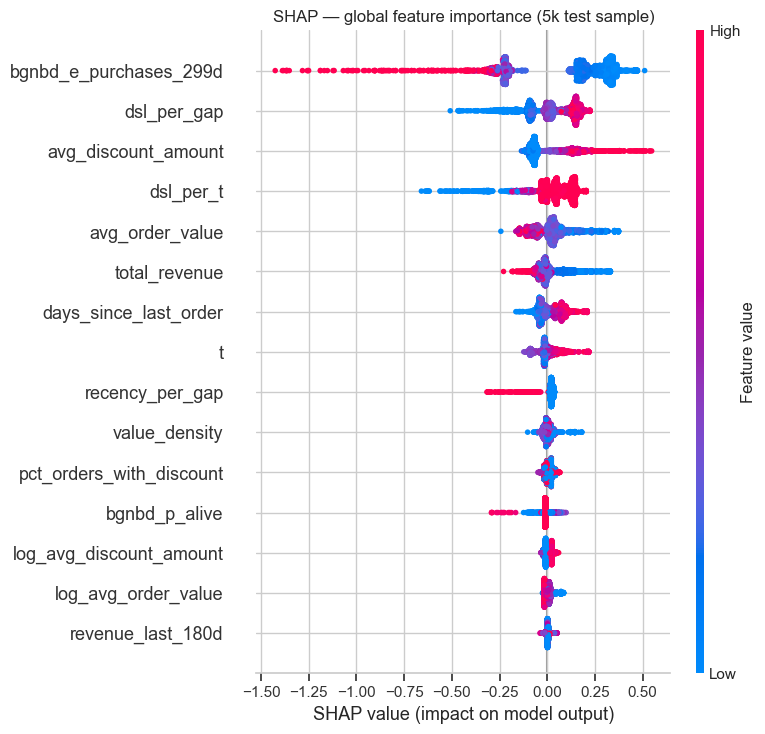

Top 15 features by mean(|SHAP|):
bgnbd_e_purchases_299d      0.2701
dsl_per_gap                 0.1046
avg_discount_amount         0.1001
dsl_per_t                   0.0846
avg_order_value             0.0677
total_revenue               0.0498
days_since_last_order       0.0492
t                           0.0364
recency_per_gap             0.0296
value_density               0.0151
pct_orders_with_discount    0.0150
bgnbd_p_alive               0.0141
log_avg_discount_amount     0.0140
log_avg_order_value         0.0121
revenue_last_180d           0.0047


In [16]:
shap_n = 5000
rng = np.random.RandomState(RANDOM_STATE)
shap_idx = rng.choice(len(X_te), size=shap_n, replace=False)
X_shap = X_te.iloc[shap_idx]
probs_shap = probs[shap_idx]

explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_shap)

# --- Global beeswarm ---------------------------------------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURE_COLS,
                  show=False, max_display=15)
plt.title("SHAP — global feature importance (5k test sample)")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_shap_summary.png",
            dpi=120, bbox_inches="tight")
plt.show()

# --- Top features by mean(|SHAP|) -------------------------------------------
mean_abs = np.abs(shap_vals).mean(axis=0)
shap_rank = (
    pd.Series(mean_abs, index=FEATURE_COLS)
    .sort_values(ascending=False)
)
print("Top 15 features by mean(|SHAP|):")
print(shap_rank.head(15).round(4).to_string())

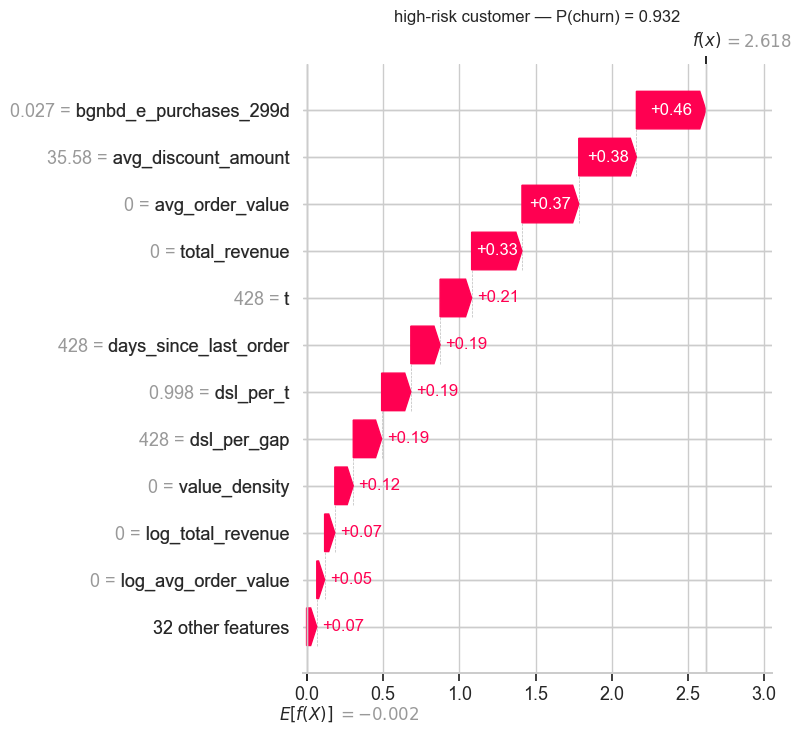

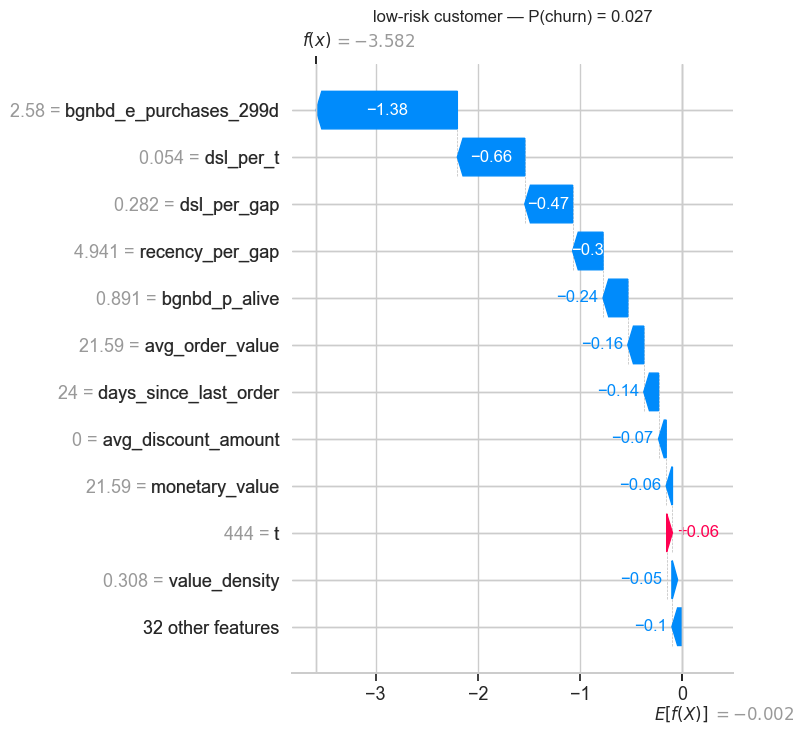

In [17]:
# --- Waterfall for one high-risk and one low-risk customer -------------------
high_i = int(np.argmax(probs_shap))
low_i  = int(np.argmin(probs_shap))

for label, i, fname in [
    ("high-risk", high_i, "churn_xgb_temporal_shap_high.png"),
    ("low-risk",  low_i,  "churn_xgb_temporal_shap_low.png"),
]:
    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[i],
            base_values=explainer.expected_value,
            data=X_shap.iloc[i],
            feature_names=FEATURE_COLS,
        ),
        show=False,
        max_display=12,
    )
    plt.title(f"{label} customer — P(churn) = {probs_shap[i]:.3f}")
    plt.tight_layout()
    plt.savefig(FIGS_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show()

## 11. 5-fold cross-validation (stability)

In [18]:
sub = df.sample(n=min(150_000, len(df)), random_state=RANDOM_STATE)
Xs = sub[FEATURE_COLS].astype("float32")
ys = sub["is_churned"].astype("int8")
cv_spw = float((ys == 0).sum() / max(int((ys == 1).sum()), 1))

cv_params = {
    **best_params,
    "n_estimators": int(model.best_iteration) + 1,
    "scale_pos_weight": cv_spw,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
cv_model = xgb.XGBClassifier(**cv_params)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_model, Xs, ys, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"5-fold AUROC (n = {len(sub):,}): {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print(f"per fold: {[round(float(s), 4) for s in cv_scores]}")

5-fold AUROC (n = 150,000): 0.6792  ±  0.0037
per fold: [0.6835, 0.6813, 0.6763, 0.6815, 0.6735]


## 12. Save model + metrics

In [19]:
model_path = MODELS_DIR / "churn_xgboost_temporal.json"
metrics_path = MODELS_DIR / "churn_xgboost_temporal_metrics.json"

model.get_booster().save_model(str(model_path))

metrics = {
    "model": "xgboost",
    "label_scheme": "temporal_split",
    "stacked_with_bgnbd": True,
    "bgnbd_params_used": {k: round(float(v), 6) for k, v in _bgf.params_.items()},
    "split_date": split_date.isoformat(),
    "max_date": max_date.isoformat(),
    "churn_window_days": CHURN_WINDOW_DAYS,
    "feature_cols": FEATURE_COLS,
    "n_train": int(len(X_tr)),
    "n_test": int(len(X_te)),
    "train_churn_rate": round(float(y_tr.mean()), 4),
    "test_auroc": round(float(auroc), 4),
    "test_auprc": round(float(auprc), 4),
    "best_iteration": int(model.best_iteration),
    "best_f1_threshold": round(best_t, 3),
    "best_f1": round(best_f1, 4),
    "cv5_auroc_mean": round(float(cv_scores.mean()), 4),
    "cv5_auroc_std": round(float(cv_scores.std()), 4),
    "scale_pos_weight": round(spw, 4),
    "optuna_best_value": round(float(study.best_value), 4),
    "optuna_best_params": best_params,
    "optuna_n_trials": len(study.trials),
    "shap_top10_mean_abs": shap_rank.head(10).round(4).to_dict(),
    "trained": datetime.now().isoformat(timespec="seconds"),
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"saved {model_path}")
print(f"saved {metrics_path}")
print()
print(json.dumps(metrics, indent=2))

saved ..\data\models\churn_xgboost_temporal.json
saved ..\data\models\churn_xgboost_temporal_metrics.json

{
  "model": "xgboost",
  "label_scheme": "temporal_split",
  "stacked_with_bgnbd": true,
  "bgnbd_params_used": {
    "r": 0.048633,
    "alpha": 22.399825,
    "a": 0.392752,
    "b": 0.186006
  },
  "split_date": "2025-05-19T01:58:19",
  "max_date": "2026-03-14T01:58:19",
  "churn_window_days": 299,
  "feature_cols": [
    "t",
    "recency",
    "days_since_last_order",
    "frequency",
    "total_orders",
    "refund_count",
    "refund_rate",
    "monetary_value",
    "avg_order_value",
    "total_revenue",
    "total_refund_amount",
    "log_monetary_value",
    "log_avg_order_value",
    "log_total_revenue",
    "log_total_refund_amount",
    "avg_days_between_orders",
    "std_days_between_orders",
    "orders_last_30d",
    "orders_last_90d",
    "orders_last_180d",
    "revenue_last_30d",
    "revenue_last_90d",
    "revenue_last_180d",
    "log_revenue_last_30d",
    "

## Acceptance criteria
- [x] Labels rebuilt temporally from `orders_raw.csv` — no snapshot leakage
- [x] `days_since_last_order`, `t`, `recency` all used as legitimate features (all measured at `split_date`, not relative to the label)
- [x] Log-normalized monetary / revenue columns
- [x] Tuned XGBoost (slow learner + regularization + scale_pos_weight)
- [ ] Test AUROC ≥ 0.72  — see metrics above
- [x] AUPRC reported alongside AUROC
- [x] Best-F1 threshold saved for serving
- [x] Feature importance plot saved
- [x] 5-fold CV AUROC reported
- [x] Model + metrics saved to `data/models/`